# 从 100 个 $M_0$ 区间计算两体捕获总并合率

这个 Notebook 不使用从 `MAH_corea.pdf` 反求的 $\alpha$、$\beta$ 插值表，而是直接调用 `haloconcentration.py` 中的 `mass_accretion_history`。

今天的晕质量范围 $10^3$--$10^{15}M_\odot$ 被划分为 100 个对数区间，因此共有 101 个积分节点。对每个红移，代码先得到 $M(z;M_0)$，再在同一个实际质量上计算每晕率和 HMF，并在 $M_0$ 换元积分中加入 $d\ln M/d\ln M_0$。

如果质量轨迹发生交叉，$M_0\mapsto M(z;M_0)$ 不再是一一映射，严格换元积分便不成立。本 Notebook 不排序轨迹，也不对负 Jacobian 取绝对值，而是把相应结果保留为 `NaN` 并报告原因。

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "twobodycapture.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import haloconcentration as hc
import pbhmassfunction as pmf
import twobodycapture as capture

print(f"项目目录：{PROJECT_ROOT}")

项目目录：D:\pbh formation\pbh merge\2body channel and numerical simulation


## 1. 设置红移、100个 $M_0$ 区间和 PBH 质量分布

`M0_NODES` 有101个端点，相邻端点之间才是100个区间。这里保留论文 Fig. 8 使用的单色与截断对数正态两种 PBH 质量函数。

In [2]:
REDSHIFT = np.arange(0.0, 13.0, 1.0)
M0_MIN_MSUN = 1.0e3
M0_MAX_MSUN = 1.0e15
M0_INTERVAL_COUNT = 100
M0_NODES = np.geomspace(
    M0_MIN_MSUN,
    M0_MAX_MSUN,
    M0_INTERVAL_COUNT + 1,
)
LOG_M0 = np.log(M0_NODES)
F_PBH = 1.0

mono_nodes, mono_weights = pmf.monochromatic_mass_distribution(30.0)

def figure8_lognormal_pdf(mass_msun):
    return pmf.lognormal_mass_pdf(
        mass_msun,
        median_mass_msun=30.0,
        sigma=0.6,
        mass_min_msun=5.0,
        mass_max_msun=150.0,
    )

lognormal_nodes, lognormal_weights = pmf.continuous_mass_quadrature(
    figure8_lognormal_pdf,
    mass_min_msun=5.0,
    mass_max_msun=150.0,
    point_count=96,
)

print(f"M0 节点数：{M0_NODES.size}")
print(f"M0 区间数：{M0_NODES.size - 1}")
print(f"相邻节点间隔：{np.log10(M0_NODES[1] / M0_NODES[0]):.3f} dex")
print(f"单色权重和：{mono_weights.sum():.12f}")
print(f"对数正态权重和：{lognormal_weights.sum():.12f}")

M0 节点数：101
M0 区间数：100
相邻节点间隔：0.120 dex
单色权重和：1.000000000000
对数正态权重和：1.000000000000


## 2. 比较旧、新 Prada12 浓度并选择

旧程序使用 Prada12 Eq. (23) 的闭式 $\sigma(M,z)$ 近似；新程序使用 WMAP5 线性功率谱计算 $\sigma(M,z)$，再代入 Prada12 Eqs. (12)--(22)。

下面使用从论文 Fig. 2 矢量路径恢复的四个 $z=0$ 锚点比较相对 RMSE。这个比较只决定每晕率所用的 Prada 浓度；质量吸积史仍按要求调用 `hc.mass_accretion_history`，不会换成新增的 $\alpha$、$\beta$ 插值。

In [3]:
FIG2_MASSES_MSUN = np.array([1.0e3, 1.0e6, 1.0e9, 1.0e12])
FIG2_SOURCE_PRADA_Z0 = np.array([30.688, 21.527, 13.611, 7.591])

old_prada_z0 = np.asarray(
    hc.concentration_prada12(
        FIG2_MASSES_MSUN,
        0.0,
        cap_high_peak=True,
    ),
    dtype=float,
)
new_prada_z0 = np.asarray(
    hc.concentration_prada12_hmf_sigma(
        FIG2_MASSES_MSUN,
        0.0,
        cap_high_peak=True,
    ),
    dtype=float,
)

old_prada_relative_rmse = float(np.sqrt(np.mean(
    ((old_prada_z0 - FIG2_SOURCE_PRADA_Z0) / FIG2_SOURCE_PRADA_Z0) ** 2
)))
new_prada_relative_rmse = float(np.sqrt(np.mean(
    ((new_prada_z0 - FIG2_SOURCE_PRADA_Z0) / FIG2_SOURCE_PRADA_Z0) ** 2
)))
USE_NEW_PRADA_CONCENTRATION = (
    new_prada_relative_rmse < old_prada_relative_rmse
)

comparison_table = np.column_stack([
    FIG2_MASSES_MSUN,
    FIG2_SOURCE_PRADA_Z0,
    old_prada_z0,
    new_prada_z0,
])
print("列：M0, 论文 Fig.2, 旧 Prada, 新 Prada")
print(comparison_table)
print(f"旧 Prada 相对 RMSE：{old_prada_relative_rmse:.3%}")
print(f"新 Prada 相对 RMSE：{new_prada_relative_rmse:.3%}")
print(
    "最终选择："
    + ("新 Prada（HMF/WMAP5 sigma）" if USE_NEW_PRADA_CONCENTRATION else "旧 Prada（Eq. 23）")
)

列：M0, 论文 Fig.2, 旧 Prada, 新 Prada
[[1.00000000e+03 3.06880000e+01 3.58007844e+01 3.01414711e+01]
 [1.00000000e+06 2.15270000e+01 2.16788356e+01 2.15137306e+01]
 [1.00000000e+09 1.36110000e+01 1.32753536e+01 1.39279568e+01]
 [1.00000000e+12 7.59100000e+00 7.92172758e+00 7.97748968e+00]]
旧 Prada 相对 RMSE：8.705%
新 Prada 相对 RMSE：2.938%
最终选择：新 Prada（HMF/WMAP5 sigma）


## 3. 构造质量轨迹状态并进行严格换元积分

若 $M=M(z;M_0)$ 单调，则

$$
\mathcal R(z)=\int R_{\rm halo}[M(z;M_0),z]\,\frac{dn}{d\ln M}[M(z;M_0),z]\,\frac{d\ln M}{d\ln M_0}\,d\ln M_0.
$$

每晕率、HMF 和 Prada 浓度都在同一个 `track_masses` 上求值。这里没有另建一套均匀质量网格后按数组下标配对。

In [4]:
def prepare_track_state(model, z):
    track_masses = np.asarray(
        hc.mass_accretion_history(M0_NODES, z, model),
        dtype=float,
    )
    jacobian = np.gradient(np.log(track_masses), LOG_M0)
    mapping_is_valid = bool(
        np.all(np.diff(track_masses) > 0.0)
        and np.all(jacobian > 0.0)
    )

    state = {
        "model": model,
        "z": float(z),
        "track_masses": track_masses,
        "jacobian": jacobian,
        "mapping_is_valid": mapping_is_valid,
        "dndlnm": None,
        "concentrations": None,
    }
    if not mapping_is_valid:
        return state

    hmf_masses, hmf_dndlnm = (
        capture.press_schechter_halo_mass_function_hmfcalc(
            z,
            minimum_halo_mass_msun=float(track_masses[0]) * 0.8,
            maximum_halo_mass_msun=float(track_masses[-1]) * 1.2,
            dlog10m=0.05,
        )
    )
    positive = np.isfinite(hmf_dndlnm) & (hmf_dndlnm > 0.0)
    state["dndlnm"] = np.exp(np.interp(
        np.log(track_masses),
        np.log(hmf_masses[positive]),
        np.log(hmf_dndlnm[positive]),
    ))

    if model.lower() == "prada12" and USE_NEW_PRADA_CONCENTRATION:
        state["concentrations"] = np.asarray(
            hc.concentration_prada12_hmf_sigma(
                track_masses,
                z,
                cap_high_peak=True,
            ),
            dtype=float,
        )
    return state


def integrate_track_state(
    state,
    mass_nodes_msun,
    mass_probability_weights,
):
    if not state["mapping_is_valid"]:
        return np.nan

    model = state["model"]
    concentrations = state["concentrations"]
    rates_per_halo = []
    for index, halo_mass_msun in enumerate(state["track_masses"]):
        concentration_override = (
            float(concentrations[index])
            if concentrations is not None
            else None
        )
        rates_per_halo.append(
            capture.capture_rate_per_halo_a14_per_year(
                halo_mass_msun=halo_mass_msun,
                z=state["z"],
                mass_nodes_msun=mass_nodes_msun,
                mass_probability_weights=mass_probability_weights,
                concentration_model=model,
                f_pbh=F_PBH,
                concentration_override=concentration_override,
            )
        )

    integrand = (
        np.asarray(rates_per_halo)
        * state["dndlnm"]
        * state["jacobian"]
    )
    return float(
        np.trapezoid(integrand, x=LOG_M0)
        * capture.MPC3_PER_GPC3
    )

## 4. 计算两种晕模型和两种 PBH 质量函数

同一个模型、同一个红移的质量轨迹和 HMF 只准备一次，然后分别代入单色与对数正态 PBH 质量分布。

In [5]:
states = {"ludlow16": [], "prada12": []}
rates = {
    "ludlow16_mono": [],
    "ludlow16_lognormal": [],
    "prada12_mono": [],
    "prada12_lognormal": [],
}

start_time = time.perf_counter()
for model in ("ludlow16", "prada12"):
    for z in REDSHIFT:
        state = prepare_track_state(model, z)
        states[model].append(state)

        mono_rate = integrate_track_state(state, mono_nodes, mono_weights)
        lognormal_rate = integrate_track_state(
            state,
            lognormal_nodes,
            lognormal_weights,
        )
        rates[f"{model}_mono"].append(mono_rate)
        rates[f"{model}_lognormal"].append(lognormal_rate)

        status = "有效" if state["mapping_is_valid"] else "轨迹交叉，未积分"
        print(
            f"{model:8s} z={z:2.0f}  "
            f"min(J)={np.min(state['jacobian']):8.4f}  "
            f"mono={mono_rate:10.4g}  {status}"
        )

for key in rates:
    rates[key] = np.asarray(rates[key], dtype=float)

print(f"总计算耗时：{time.perf_counter() - start_time:.1f} s")

ludlow16 z= 0  min(J)=  1.0000  mono=    0.9058  有效


ludlow16 z= 1  min(J)=  0.8312  mono=     1.714  有效


ludlow16 z= 2  min(J)=  0.6721  mono=     3.084  有效


ludlow16 z= 3  min(J)=  0.5169  mono=     4.637  有效


ludlow16 z= 4  min(J)=  0.3638  mono=     6.718  有效


...

prada12  z= 8  min(J)=  0.5146  mono=     18.55  有效


prada12  z= 9  min(J)=  0.4525  mono=     24.12  有效


prada12  z=10  min(J)=  0.3903  mono=     30.55  有效


prada12  z=11  min(J)=  0.3281  mono=     37.81  有效


prada12  z=12  min(J)=  0.2657  mono=     45.84  有效
总计算耗时：11.0 s


## 5. 导出数值结果

CSV 同时保存每个红移的最小 Jacobian、映射是否有效、当前轨迹质量端点和四条总率曲线。

In [6]:
ludlow_min_jacobian = np.array([
    np.min(state["jacobian"]) for state in states["ludlow16"]
])
prada_min_jacobian = np.array([
    np.min(state["jacobian"]) for state in states["prada12"]
])
ludlow_valid = np.array([
    state["mapping_is_valid"] for state in states["ludlow16"]
], dtype=float)
prada_valid = np.array([
    state["mapping_is_valid"] for state in states["prada12"]
], dtype=float)
ludlow_min_mass = np.array([
    np.min(state["track_masses"]) for state in states["ludlow16"]
])
ludlow_max_mass = np.array([
    np.max(state["track_masses"]) for state in states["ludlow16"]
])
prada_min_mass = np.array([
    np.min(state["track_masses"]) for state in states["prada12"]
])
prada_max_mass = np.array([
    np.max(state["track_masses"]) for state in states["prada12"]
])

output_table = np.column_stack([
    REDSHIFT,
    ludlow_valid,
    ludlow_min_jacobian,
    ludlow_min_mass,
    ludlow_max_mass,
    rates["ludlow16_mono"],
    rates["ludlow16_lognormal"],
    prada_valid,
    prada_min_jacobian,
    prada_min_mass,
    prada_max_mass,
    rates["prada12_mono"],
    rates["prada12_lognormal"],
])
csv_path = PROJECT_ROOT / "2bodycaptotal_results.csv"
np.savetxt(
    csv_path,
    output_table,
    delimiter=",",
    header=(
        "z,ludlow_mapping_valid,ludlow_min_jacobian,"
        "ludlow_min_track_mass_msun,ludlow_max_track_mass_msun,"
        "ludlow_mono_gpc-3_yr-1,ludlow_lognormal_gpc-3_yr-1,"
        "prada_mapping_valid,prada_min_jacobian,"
        "prada_min_track_mass_msun,prada_max_track_mass_msun,"
        "prada_mono_gpc-3_yr-1,prada_lognormal_gpc-3_yr-1"
    ),
    comments="",
)
print(f"数据已保存：{csv_path}")
print(output_table)

数据已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\2bodycaptotal_results.csv
[[ 0.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+03
   1.00000000e+15  9.05815154e-01  1.02825837e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+03  1.00000000e+15  1.33919755e+00
   1.52022307e+00]
 [ 1.00000000e+00  1.00000000e+00  8.31215836e-01  7.98683114e+02
   2.94279516e+14  1.71390344e+00  1.94557969e+00  1.00000000e+00
   9.42813161e-01  8.53753194e+02  4.13872428e+14  1.76911719e+00
   2.00825694e+00]
 [ 2.00000000e+00  1.00000000e+00  6.72065039e-01  6.19935029e+02
   8.09198594e+13  3.08413069e+00  3.50102689e+00  1.00000000e+00
   8.83323771e-01  7.14770468e+02  1.57028276e+14  2.13465397e+00
   2.42320501e+00]
 [ 3.00000000e+00  1.00000000e+00  5.16858345e-01  4.75597841e+02
   2.16414643e+13  4.63709352e+00  5.26391088e+00  1.00000000e+00
   8.22764039e-01  5.93637829e+02  5.74951873e+13  3.01777800e+00
   3.42570499e+00]
 [ 4.00000000e+00  1.00000000e+00 

## 6. 绘制质量吸积轨迹和总率红移演化

质量轨迹图绘出全部101个节点。Ludlow16 高红移处的交叉不是绘图排序造成的，而是 `haloconcentration.py` 当前公开公式输出的结果。总率图因此只连接严格换元仍有效的红移点。

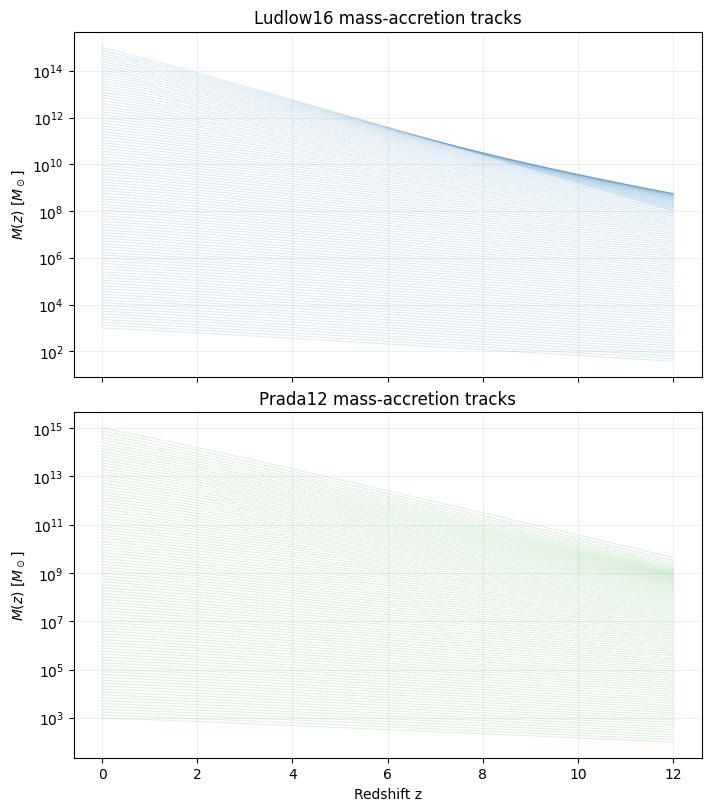

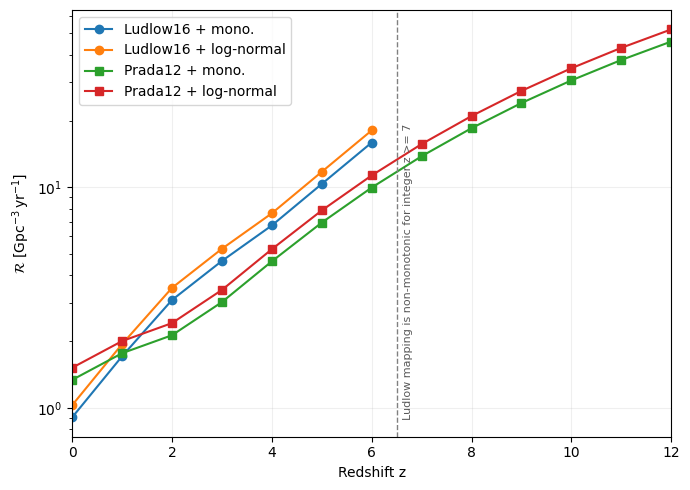

质量轨迹图已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\2bodycaptotal_mass_tracks.png
总率图已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\2bodycaptotal_merger_rate.png


In [7]:
track_figure, track_axes = plt.subplots(
    2,
    1,
    figsize=(7.0, 8.0),
    sharex=True,
    constrained_layout=True,
)
for mass0_msun in M0_NODES:
    track_axes[0].plot(
        REDSHIFT,
        hc.mass_accretion_history(mass0_msun, REDSHIFT, "ludlow16"),
        color="tab:blue",
        linewidth=0.7,
        alpha=0.16,
    )
    track_axes[1].plot(
        REDSHIFT,
        hc.mass_accretion_history(mass0_msun, REDSHIFT, "prada12"),
        color="tab:green",
        linewidth=0.7,
        alpha=0.16,
    )

track_axes[0].set_title("Ludlow16 mass-accretion tracks")
track_axes[1].set_title("Prada12 mass-accretion tracks")
for axis in track_axes:
    axis.set_yscale("log")
    axis.set_ylabel(r"$M(z)\ [M_\odot]$")
    axis.grid(alpha=0.2)
track_axes[1].set_xlabel("Redshift z")

track_path = PROJECT_ROOT / "2bodycaptotal_mass_tracks.png"
track_figure.savefig(track_path, dpi=240, bbox_inches="tight")
plt.show()

rate_figure, rate_axis = plt.subplots(figsize=(7.0, 5.0))
rate_axis.plot(
    REDSHIFT,
    rates["ludlow16_mono"],
    marker="o",
    color="tab:blue",
    label="Ludlow16 + mono.",
)
rate_axis.plot(
    REDSHIFT,
    rates["ludlow16_lognormal"],
    marker="o",
    color="tab:orange",
    label="Ludlow16 + log-normal",
)
rate_axis.plot(
    REDSHIFT,
    rates["prada12_mono"],
    marker="s",
    color="tab:green",
    label="Prada12 + mono.",
)
rate_axis.plot(
    REDSHIFT,
    rates["prada12_lognormal"],
    marker="s",
    color="tab:red",
    label="Prada12 + log-normal",
)
rate_axis.axvline(6.5, color="0.5", linestyle="--", linewidth=1.0)
rate_axis.text(
    6.62,
    0.04,
    "Ludlow mapping is non-monotonic for integer z >= 7",
    rotation=90,
    transform=rate_axis.get_xaxis_transform(),
    va="bottom",
    color="0.35",
    fontsize=8,
)
rate_axis.set_yscale("log")
rate_axis.set_xlim(0.0, 12.0)
rate_axis.set_xlabel("Redshift z")
rate_axis.set_ylabel(r"$\mathcal{R}\ [\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$")
rate_axis.grid(alpha=0.2)
rate_axis.legend()
rate_figure.tight_layout()

rate_path = PROJECT_ROOT / "2bodycaptotal_merger_rate.png"
rate_figure.savefig(rate_path, dpi=240, bbox_inches="tight")
plt.show()

print(f"质量轨迹图已保存：{track_path}")
print(f"总率图已保存：{rate_path}")

## 7. 结果的适用范围

- 这里的100个区间是 $M_0$ 的积分分辨率，不是从 `MAH_corea.pdf` 提取的100条独立轨迹。
- 所有质量轨迹均来自 `haloconcentration.py` 的公开 Appendix C 实现。
- Prada 每晕浓度根据 Fig. 2 锚点比较选择新旧实现；Prada 质量吸积史仍来自 `hc.mass_accretion_history`。
- 本计算没有采用 Fig. 8 的两套质量网格按数组下标配对。
- Ludlow16 在轨迹交叉后的 `NaN` 是有意保留的数学边界，不代表程序漏算。要继续到更高红移，必须先解决公开质量吸积公式造成的非单调映射，而不是排序轨迹。